# Cell 1 — NA-HQKVE-IDS PAPER_FULL V3

# Corrected PAPER_FULL V3 — NA-HQKVE-IDS

This notebook is the publication-grade successor to the Paper Core and QKA-repair studies.

## Repaired QKA configuration used in V3

The repair experiment identified the healthy QKA design as:

**latent features → per-qubit trainable `RY(θ_i)` → `zz_feature_map(reps=1, linear)` → `TrainableFidelityStatevectorKernel` → `QuantumKernelTrainer(loss="svc_loss")` → COBYLA → precomputed SVC**

For every independent seed, QKA starts again from a zero vector. The diagnostic optimum is **not** hard-coded.

## Main experiments

- Five independent seeds: `11, 22, 33, 44, 55`
- 4-qubit vs 6-qubit ablation
- 50, 100 and 250 training samples/class
- Matched-data LightGBM baseline
- Full-data LightGBM practical upper baseline
- Fixed fidelity quantum kernel
- Repaired QKA-QSVC
- Prototype-reduced QKA
- Shallow VQC
- QKA + VQC + LightGBM + AE-error stack
- Exact vs finite-shot quantum-kernel evaluation
- Per-configuration five-seed statistical tests
- Holm correction
- Friedman test
- paired effect size
- McNemar test from prediction-level outputs

## Duplicate prevention

Every experiment has a deterministic SHA-1 `experiment_id` generated from:

`model + seed + qubits + training size + prototype size + shots + scenario`

The result store is keyed by this ID. Re-running a cell **skips an already completed experiment instead of appending another row**.

## Resource policy

Full exact QKA is run by default through 100 training samples/class. At 250/class the notebook uses prototype-QKA by default because QKA optimization repeatedly constructs an O(N²) kernel. Set `ALLOW_FULL_QKA_250=True` only if you deliberately want that expensive run.

In [1]:
# Cell 2 — Install publication environment
!pip -q install \
    "qiskit>=2.2" \
    "qiskit-machine-learning>=0.9.0" \
    "qiskit-aer>=0.17"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00


In [2]:
# Cell 3 — Imports, versions and global configuration
import os, time, json, random, hashlib, warnings, platform, shutil
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, friedmanchisquare
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, brier_score_loss, confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import qiskit
import qiskit_machine_learning
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.primitives import StatevectorSampler

from qiskit_machine_learning.kernels import (
    FidelityStatevectorKernel,
    TrainableFidelityStatevectorKernel
)
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.utils import algorithm_globals

print("Python:", platform.python_version())
print("Qiskit:", qiskit.__version__)
print("Qiskit ML:", qiskit_machine_learning.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", DEVICE)


Python: 3.12.13
Qiskit: 2.5.2
Qiskit ML: 0.9.0
Torch: 2.11.0+cu128
CUDA available: True
Torch device: cuda


In [3]:
# Cell 4 — PAPER_FULL experiment settings
SEEDS = [11, 22, 33, 44, 55]
QUBITS = [4, 6]
TRAIN_PER_CLASS_LIST = [50, 100, 250]

VAL_PER_CLASS = 100
TEST_PER_CLASS = 250

PROTOTYPES_PER_CLASS_LIST = [20, 50, 100]

TOP_MI = 25
TOP_FINAL = 12

AE_EPOCHS = 60
QKA_MAXITER = 40
VQC_MAXITER = 50

SHOT_LIST = [1024, 2048, 4096]

# Repaired QKA:
QKA_PARAMETERIZATION = "per_qubit"
QKA_OPTIMIZER = "COBYLA"
QKA_INITIALIZATION = "zeros"

# Resource safeguard.
FULL_QKA_MAX_TRAIN_PER_CLASS = 100
ALLOW_FULL_QKA_250 = False

# Experiment switches.
RUN_FIXED_QK = True
RUN_QKA = True
RUN_PROTOTYPE_QKA = True
RUN_VQC = True
RUN_STACK = True
RUN_SHOT_EXPERIMENTS = True

# Shot experiments are run at the largest feasible exact-QKA training size.
SHOT_TRAIN_PER_CLASS = 100

PAPER_CORE_FEATURES = [
    "sttl", "ct_state_ttl", "state_INT", "ct_dst_sport_ltm",
    "synack", "tcprtt", "dbytes", "smean",
    "ct_srv_dst", "sbytes", "rate", "dmean"
]

print("Seeds:", SEEDS)
print("Qubits:", QUBITS)
print("Train/class:", TRAIN_PER_CLASS_LIST)
print("QKA:", QKA_PARAMETERIZATION, QKA_OPTIMIZER, QKA_INITIALIZATION)


Seeds: [11, 22, 33, 44, 55]
Qubits: [4, 6]
Train/class: [50, 100, 250]
QKA: per_qubit COBYLA zeros


In [4]:
# Cell 5 — QKA API preflight
# Small preflight so an API incompatibility is caught before the full experiment.

X_demo = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [2.7, 2.8],
    [2.8, 2.7]
])
y_demo = np.array([0, 0, 1, 1])

theta_demo = ParameterVector("theta_demo", 2)
layer_demo = QuantumCircuit(2)
for q in range(2):
    layer_demo.ry(theta_demo[q], q)

fmap_demo = layer_demo.compose(
    zz_feature_map(2, reps=1, entanglement="linear")
)

kernel_demo = TrainableFidelityStatevectorKernel(
    feature_map=fmap_demo,
    training_parameters=theta_demo,
    shots=None,
    enforce_psd=True
)

trainer_demo = QuantumKernelTrainer(
    quantum_kernel=kernel_demo,
    loss="svc_loss",
    optimizer=COBYLA(maxiter=2),
    initial_point=np.zeros(2)
)

demo_result = trainer_demo.fit(X_demo, y_demo)

print("QKA preflight PASSED")
print("Optimal value:", demo_result.optimal_value)
print("Optimal point:", demo_result.optimal_point)


QKA preflight PASSED
Optimal value: 1.3782423482199713
Optimal point: [-0.70710678 -0.70710678]


In [5]:
# Cell 6 — Upload UNSW-NB15 train and test files
from google.colab import files

print("Upload:")
print("  UNSW_NB15_training-set.csv")
print("  UNSW_NB15_testing-set.csv")

uploaded = files.upload()

csv_files = list(Path("/content").glob("*.csv"))

def locate_csv(keys):
    for p in csv_files:
        n = p.name.lower()
        if all(k in n for k in keys):
            return str(p)
    return None

TRAIN_PATH = locate_csv(["training"]) or locate_csv(["train"])
TEST_PATH = locate_csv(["testing"]) or locate_csv(["test"])

if TRAIN_PATH is None or TEST_PATH is None:
    raise FileNotFoundError("Could not detect standard UNSW-NB15 training/testing CSV files.")

print("Train:", TRAIN_PATH)
print("Test :", TEST_PATH)


Upload:
  UNSW_NB15_training-set.csv
  UNSW_NB15_testing-set.csv


FileNotFoundError: Could not detect standard UNSW-NB15 training/testing CSV files.

In [6]:
# Cell 7 — Load and clean binary IDS data

from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the paths to your datasets
TRAIN_PATH = '/content/drive/MyDrive/PhD_Work/Dataset/UNSW_NB15/UNSW_NB15_training-set.csv'
TEST_PATH = '/content/drive/MyDrive/PhD_Work/Dataset/UNSW_NB15/UNSW_NB15_testing-set.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

if "label" not in train_df.columns or "label" not in test_df.columns:
    raise ValueError("Expected binary column 'label'.")

for df in (train_df, test_df):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

DROP = ["id", "attack_cat"]

X_train_raw = train_df.drop(
    columns=[c for c in DROP + ["label"] if c in train_df.columns]
).copy()

X_test_raw = test_df.drop(
    columns=[c for c in DROP + ["label"] if c in test_df.columns]
).copy()

X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns)

y_train = train_df["label"].astype(int).to_numpy()
y_test = test_df["label"].astype(int).to_numpy()

cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

X_train_raw[num_cols] = X_train_raw[num_cols].apply(pd.to_numeric, errors="coerce")
X_test_raw[num_cols] = X_test_raw[num_cols].apply(pd.to_numeric, errors="coerce")

medians = X_train_raw[num_cols].median()
X_train_raw[num_cols] = X_train_raw[num_cols].fillna(medians)
X_test_raw[num_cols] = X_test_raw[num_cols].fillna(medians)

for c in cat_cols:
    X_train_raw[c] = X_train_raw[c].fillna("MISSING").astype(str)
    X_test_raw[c] = X_test_raw[c].fillna("MISSING").astype(str)

print("Train:", X_train_raw.shape, np.bincount(y_train))
print("Test :", X_test_raw.shape, np.bincount(y_test))


Mounted at /content/drive
Train: (82332, 42) [37000 45332]
Test : (175341, 42) [ 56000 119341]


In [7]:
# Cell 8 — Leakage-safe encoding and robust scaling
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    verbose_feature_names_out=False
)

Xtr = preprocessor.fit_transform(X_train_raw)
Xte = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

Xtr = pd.DataFrame(Xtr, columns=feature_names)
Xte = pd.DataFrame(Xte, columns=feature_names)

print("Preprocessed train:", Xtr.shape)
print("Preprocessed test :", Xte.shape)


Preprocessed train: (82332, 190)
Preprocessed test : (175341, 190)


In [8]:
# Cell 9 — Fix the Paper Core feature set or recompute once
available = [f for f in PAPER_CORE_FEATURES if f in Xtr.columns]

if len(available) == len(PAPER_CORE_FEATURES):
    SELECTED_FEATURES = PAPER_CORE_FEATURES.copy()
    print("Using exact Paper Core / repair feature set.")
else:
    print("Paper Core feature names not fully available. Recomputing once.")

    mi = mutual_info_classif(Xtr, y_train, random_state=42)
    mi_scores = pd.Series(mi, index=Xtr.columns).sort_values(ascending=False)
    top_mi = mi_scores.head(TOP_MI).index.tolist()

    selector = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        tree_method="hist",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
    selector.fit(Xtr[top_mi], y_train)

    importance = pd.Series(
        selector.feature_importances_,
        index=top_mi
    ).sort_values(ascending=False)

    SELECTED_FEATURES = importance.head(TOP_FINAL).index.tolist()

print("Selected features:")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(i, f)

Xtr_selected = Xtr[SELECTED_FEATURES].to_numpy(np.float32)
Xte_selected = Xte[SELECTED_FEATURES].to_numpy(np.float32)


Using exact Paper Core / repair feature set.
Selected features:
1 sttl
2 ct_state_ttl
3 state_INT
4 ct_dst_sport_ltm
5 synack
6 tcprtt
7 dbytes
8 smean
9 ct_srv_dst
10 sbytes
11 rate
12 dmean


In [9]:
# Cell 10 — Persistent duplicate-safe experiment store
OUT = Path("/content/drive/MyDrive/PhD_Work/NA_HQKVE_IDS_V3")
OUT.mkdir(exist_ok=True)

RESULTS_PATH = OUT / "results_long.csv"
PREDICTIONS_PATH = OUT / "predictions_long.csv"

RESULTS_BY_ID = {}
PREDICTIONS_BY_ID = {}

def experiment_id(model, seed, qubits, train_per_class,
                  prototypes_per_class=0, shots=0, scenario="clean"):
    payload = {
        "model": str(model),
        "seed": int(seed),
        "qubits": int(qubits),
        "train_per_class": int(train_per_class),
        "prototypes_per_class": int(prototypes_per_class),
        "shots": int(shots),
        "scenario": str(scenario),
    }
    raw = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    return hashlib.sha1(raw.encode()).hexdigest()[:16]

def load_checkpoint():
    if RESULTS_PATH.exists():
        old = pd.read_csv(RESULTS_PATH)
        for _, row in old.iterrows():
            RESULTS_BY_ID[str(row["experiment_id"])] = row.to_dict()

    if PREDICTIONS_PATH.exists():
        oldp = pd.read_csv(PREDICTIONS_PATH)
        for eid, group in oldp.groupby("experiment_id"):
            PREDICTIONS_BY_ID[str(eid)] = group.copy()

    print("Loaded completed results:", len(RESULTS_BY_ID))
    print("Loaded prediction sets:", len(PREDICTIONS_BY_ID))

def save_checkpoint():
    if RESULTS_BY_ID:
        df = pd.DataFrame(list(RESULTS_BY_ID.values()))
        df = df.drop_duplicates("experiment_id", keep="last")
        df.to_csv(RESULTS_PATH, index=False)

    if PREDICTIONS_BY_ID:
        pdf = pd.concat(PREDICTIONS_BY_ID.values(), ignore_index=True)
        pdf = pdf.drop_duplicates(["experiment_id", "sample_index"], keep="last")
        pdf.to_csv(PREDICTIONS_PATH, index=False)

load_checkpoint()


Loaded completed results: 0
Loaded prediction sets: 0


In [11]:
# Cell 11 — Metrics and result registration
def binary_metrics(y_true, prob):
    prob = np.asarray(prob, float)
    pred = (prob >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "mcc": matthews_corrcoef(y_true, pred),
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob),
        "brier": brier_score_loss(y_true, prob),
        "positive_prediction_rate": float(pred.mean()),
    }

def register_result(
    model, seed, qubits, train_per_class,
    y_true, prob, sample_indices,
    prototypes_per_class=0, shots=0, scenario="clean",
    runtime_sec=np.nan, extra=None
):
    eid = experiment_id(
        model, seed, qubits, train_per_class,
        prototypes_per_class, shots, scenario
    )

    if eid in RESULTS_BY_ID:
        print("SKIP existing:", eid, model, seed, qubits, train_per_class)
        return eid

    row = {
        "experiment_id": eid,
        "model": model,
        "seed": int(seed),
        "qubits": int(qubits),
        "train_per_class": int(train_per_class),
        "prototypes_per_class": int(prototypes_per_class),
        "shots": int(shots),
        "scenario": scenario,
        "runtime_sec": float(runtime_sec),
    }
    row.update(binary_metrics(y_true, prob))

    if extra:
        row.update(extra)

    RESULTS_BY_ID[eid] = row

    pred = (np.asarray(prob) >= 0.5).astype(int)
    PREDICTIONS_BY_ID[eid] = pd.DataFrame({
        "experiment_id": eid,
        "model": model,
        "seed": int(seed),
        "qubits": int(qubits),
        "train_per_class": int(train_per_class),
        "prototypes_per_class": int(prototypes_per_class),
        "shots": int(shots),
        "scenario": scenario,
        "sample_index": np.asarray(sample_indices, int),
        "y_true": np.asarray(y_true, int),
        "probability": np.asarray(prob, float),
        "prediction": pred,
    })

    save_checkpoint()
    return eid


In [12]:
# Cell 12 — Seed-specific disjoint split generator
MAX_TRAIN_PER_CLASS = max(TRAIN_PER_CLASS_LIST)

def make_seed_split(y_train, y_test, seed):
    rng = np.random.default_rng(seed)

    train_pool_by_class = {}
    val_by_class = {}

    for cls in np.unique(y_train):
        ids = np.flatnonzero(y_train == cls).copy()
        rng.shuffle(ids)

        needed = MAX_TRAIN_PER_CLASS + VAL_PER_CLASS
        if len(ids) < needed:
            raise ValueError(f"Not enough class {cls} training samples.")

        train_pool_by_class[int(cls)] = ids[:MAX_TRAIN_PER_CLASS]
        val_by_class[int(cls)] = ids[
            MAX_TRAIN_PER_CLASS:MAX_TRAIN_PER_CLASS + VAL_PER_CLASS
        ]

    test_parts = []
    for cls in np.unique(y_test):
        ids = np.flatnonzero(y_test == cls).copy()
        rng.shuffle(ids)
        test_parts.append(ids[:TEST_PER_CLASS])

    test_idx = np.concatenate(test_parts)
    rng.shuffle(test_idx)

    val_idx = np.concatenate([val_by_class[c] for c in sorted(val_by_class)])
    rng.shuffle(val_idx)

    def train_idx(n_per_class):
        parts = [
            train_pool_by_class[c][:n_per_class]
            for c in sorted(train_pool_by_class)
        ]
        idx = np.concatenate(parts)
        # Deterministic but separately shuffled.
        local_rng = np.random.default_rng(seed * 1000 + n_per_class)
        local_rng.shuffle(idx)
        return idx

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

SPLITS = {seed: make_seed_split(y_train, y_test, seed) for seed in SEEDS}

for seed in SEEDS:
    print(
        seed,
        "val", len(SPLITS[seed]["val_idx"]),
        "test", len(SPLITS[seed]["test_idx"])
    )


11 val 200 test 500
22 val 200 test 500
33 val 200 test 500
44 val 200 test 500
55 val 200 test 500


In [13]:
# Cell 13 — Seed-specific denoising autoencoder
class DAE(nn.Module):
    def __init__(self, input_dim, latent_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 10),
            nn.ReLU(),
            nn.Linear(10, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

def train_seed_autoencoder(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    scaler = MinMaxScaler((0, 1))
    X_train_ae = scaler.fit_transform(Xtr_selected).astype(np.float32)
    X_test_ae = scaler.transform(Xte_selected).astype(np.float32)

    fit_idx, va_idx = train_test_split(
        np.arange(len(y_train)),
        test_size=0.15,
        stratify=y_train,
        random_state=seed
    )

    model = DAE(X_train_ae.shape[1], latent_dim=6).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    loader = DataLoader(
        TensorDataset(torch.tensor(X_train_ae[fit_idx], dtype=torch.float32)),
        batch_size=512 if torch.cuda.is_available() else 256,
        shuffle=True
    )

    val_tensor = torch.tensor(X_train_ae[va_idx], dtype=torch.float32, device=DEVICE)

    best_loss = np.inf
    best_state = None

    for epoch in range(1, AE_EPOCHS + 1):
        model.train()

        for (batch,) in loader:
            batch = batch.to(DEVICE)
            noisy = torch.clamp(batch + 0.05 * torch.randn_like(batch), 0, 1)

            optimizer.zero_grad()
            rec = model(noisy)
            loss = loss_fn(rec, batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(val_tensor), val_tensor).item()

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    model.load_state_dict(best_state)

    def encode_and_error(X):
        model.eval()
        t = torch.tensor(X, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            z = model.encoder(t)
            rec = model.decoder(z)
            err = torch.mean((rec - t) ** 2, dim=1)
        return z.cpu().numpy(), err.cpu().numpy()

    Ztr, Etr = encode_and_error(X_train_ae)
    Zte, Ete = encode_and_error(X_test_ae)

    err_scaler = MinMaxScaler().fit(Etr.reshape(-1, 1))

    return {
        "model": model,
        "input_scaler": scaler,
        "Ztr": Ztr,
        "Zte": Zte,
        "Etr": Etr,
        "Ete": Ete,
        "err_scaler": err_scaler,
        "best_val_mse": best_loss,
    }


In [14]:
# Cell 14 — Train/cache the five seed-specific latent representations
LATENT = {}

for seed in SEEDS:
    print("Training DAE for seed", seed)
    t0 = time.time()
    LATENT[seed] = train_seed_autoencoder(seed)
    print(
        "seed", seed,
        "best val MSE", LATENT[seed]["best_val_mse"],
        "seconds", round(time.time() - t0, 2)
    )

print("Latent representations ready.")


Training DAE for seed 11
seed 11 best val MSE 0.0023210595827549696 seconds 40.57
Training DAE for seed 22
seed 22 best val MSE 0.002367901150137186 seconds 33.78
Training DAE for seed 33
seed 33 best val MSE 0.0042220111936330795 seconds 34.78
Training DAE for seed 44
seed 44 best val MSE 0.005387674085795879 seconds 33.87
Training DAE for seed 55
seed 55 best val MSE 0.0023606049362570047 seconds 34.68
Latent representations ready.


In [15]:
# Cell 15 — Quantum-input scaler per seed and qubit count
QUANTUM_DATA = {}

for seed in SEEDS:
    QUANTUM_DATA[seed] = {}

    for nq in QUBITS:
        qscaler = MinMaxScaler((0, np.pi))

        Ztr_q = qscaler.fit_transform(LATENT[seed]["Ztr"][:, :nq])
        Zte_q = qscaler.transform(LATENT[seed]["Zte"][:, :nq])

        QUANTUM_DATA[seed][nq] = {
            "train": np.clip(Ztr_q, 0, np.pi),
            "test": np.clip(Zte_q, 0, np.pi),
            "scaler": qscaler,
        }

print("Quantum inputs ready.")


Quantum inputs ready.


In [16]:
# Cell 16 — Repaired per-qubit QKA feature map
def build_repaired_qka_feature_map(nq, tag=""):
    theta = ParameterVector(f"theta_{tag}_{nq}", nq)

    train_layer = QuantumCircuit(nq)
    for q in range(nq):
        train_layer.ry(theta[q], q)

    data_layer = zz_feature_map(
        feature_dimension=nq,
        reps=1,
        entanglement="linear"
    )

    feature_map = train_layer.compose(data_layer)
    return feature_map, theta


In [17]:
# Cell 17 — Fixed quantum-kernel helper
def fixed_kernel_predict(X_train, y_train_local, X_val, X_test, nq, shots=None):
    fmap = zz_feature_map(
        feature_dimension=nq,
        reps=1,
        entanglement="linear"
    )

    kernel = FidelityStatevectorKernel(
        feature_map=fmap,
        shots=shots,
        enforce_psd=True
    )

    t0 = time.time()

    K_train = kernel.evaluate(X_train)
    K_val = kernel.evaluate(X_val, X_train)
    K_test = kernel.evaluate(X_test, X_train)

    svc = SVC(
        kernel="precomputed",
        probability=True,
        class_weight="balanced",
        random_state=42
    )
    svc.fit(K_train, y_train_local)

    pos_col = list(svc.classes_).index(1)

    p_val = svc.predict_proba(K_val)[:, pos_col]
    p_test = svc.predict_proba(K_test)[:, pos_col]

    return {
        "p_val": p_val,
        "p_test": p_test,
        "runtime_sec": time.time() - t0,
        "kernel": kernel,
        "svc": svc,
    }


In [18]:
# Cell 18 — Repaired exact QKA helper
def repaired_qka_predict(
    X_train, y_train_local, X_val, X_test,
    nq, seed, maxiter=QKA_MAXITER
):
    fmap, theta = build_repaired_qka_feature_map(
        nq,
        tag=f"{seed}"
    )

    kernel = TrainableFidelityStatevectorKernel(
        feature_map=fmap,
        training_parameters=theta,
        shots=None,
        enforce_psd=True
    )

    optimizer = COBYLA(
        maxiter=maxiter,
        tol=1e-5
    )

    trainer = QuantumKernelTrainer(
        quantum_kernel=kernel,
        loss="svc_loss",
        optimizer=optimizer,
        initial_point=np.zeros(nq)
    )

    t0 = time.time()
    result = trainer.fit(X_train, y_train_local)

    trained_kernel = result.quantum_kernel

    K_train = trained_kernel.evaluate(X_train)
    K_val = trained_kernel.evaluate(X_val, X_train)
    K_test = trained_kernel.evaluate(X_test, X_train)

    svc = SVC(
        kernel="precomputed",
        probability=True,
        class_weight="balanced",
        random_state=seed
    )
    svc.fit(K_train, y_train_local)

    pos_col = list(svc.classes_).index(1)

    p_val = svc.predict_proba(K_val)[:, pos_col]
    p_test = svc.predict_proba(K_test)[:, pos_col]

    return {
        "p_val": p_val,
        "p_test": p_test,
        "runtime_sec": time.time() - t0,
        "trained_kernel": trained_kernel,
        "svc": svc,
        "qkt_result": result,
        "feature_map": fmap,
        "training_parameters": theta,
        "optimal_point": np.asarray(result.optimal_point, float),
        "optimal_value": float(result.optimal_value),
        "optimizer_evals": result.optimizer_evals,
    }


In [19]:
# Cell 19 — Prototype selection helper
def nearest_real_prototypes(X, y, prototypes_per_class, seed):
    selected = []

    for cls in np.unique(y):
        ids = np.flatnonzero(y == cls)
        Xc = X[ids]

        m = min(prototypes_per_class, len(ids))

        kmeans = KMeans(
            n_clusters=m,
            random_state=seed,
            n_init=10
        ).fit(Xc)

        used = set()

        for center in kmeans.cluster_centers_:
            distances = np.sum((Xc - center) ** 2, axis=1)
            order = np.argsort(distances)

            chosen_local = None
            for candidate in order:
                if int(candidate) not in used:
                    chosen_local = int(candidate)
                    break

            if chosen_local is not None:
                used.add(chosen_local)
                selected.append(ids[chosen_local])

    selected = np.asarray(selected, dtype=int)

    rng = np.random.default_rng(seed)
    rng.shuffle(selected)

    return selected


In [20]:
# Cell 20 — Shallow VQC helper
def vqc_predict(X_train, y_train_local, X_val, X_test, nq, seed):
    algorithm_globals.random_seed = seed

    fmap = zz_feature_map(
        feature_dimension=nq,
        reps=1,
        entanglement="linear"
    )

    ansatz = real_amplitudes(
        num_qubits=nq,
        reps=1,
        entanglement="linear"
    )

    sampler = StatevectorSampler(seed=seed)

    history = []

    model = VQC(
        sampler=sampler,
        feature_map=fmap,
        ansatz=ansatz,
        optimizer=COBYLA(maxiter=VQC_MAXITER),
        callback=lambda weights, objective: history.append(float(objective))
    )

    t0 = time.time()
    model.fit(X_train, y_train_local)
    sec = time.time() - t0

    p_val = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    return {
        "model": model,
        "p_val": p_val,
        "p_test": p_test,
        "runtime_sec": sec,
        "objective_history": history,
    }


In [21]:
# Cell 21 — Matched and full LightGBM helpers
def train_lgbm(X_train, y_train_local, X_val, X_test, seed):
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1,
        verbosity=-1
    )

    t0 = time.time()
    model.fit(X_train, y_train_local)
    sec = time.time() - t0

    return {
        "model": model,
        "p_val": model.predict_proba(X_val)[:, 1],
        "p_test": model.predict_proba(X_test)[:, 1],
        "runtime_sec": sec,
    }


# Cell 22 — Core five-seed experiment

The following cell is intentionally the main computation cell.

For each seed / qubit / data-size combination:

1. all models use the same held-out validation and official test samples;
2. `LightGBM_Matched` uses the same training observations as the quantum models;
3. `LightGBM_Full` is logged separately as the practical full-data classical baseline;
4. fixed QK is exact statevector;
5. repaired QKA uses per-qubit parameters, zero initialization and COBYLA;
6. prototype QKA uses **real nearest-to-cluster observations**, not synthetic centers;
7. the stack is trained only on the validation set;
8. every completed model is checkpointed immediately.

In [22]:
# Cell 23 — Run PAPER_FULL clean-model grid
CACHE = {}

for seed in SEEDS:
    split = SPLITS[seed]

    val_idx = split["val_idx"]
    test_idx = split["test_idx"]

    for nq in QUBITS:
        Ztr_lat = LATENT[seed]["Ztr"][:, :nq]
        Zte_lat = LATENT[seed]["Zte"][:, :nq]

        Xq_all_train = QUANTUM_DATA[seed][nq]["train"]
        Xq_all_test = QUANTUM_DATA[seed][nq]["test"]

        # Full classical baseline once per seed/qubits.
        full_id = experiment_id(
            "LightGBM_Full", seed, nq, -1, 0, 0, "clean"
        )

        if full_id not in RESULTS_BY_ID:
            full = train_lgbm(
                Ztr_lat, y_train,
                Ztr_lat[val_idx],
                Zte_lat[test_idx],
                seed
            )
            register_result(
                "LightGBM_Full", seed, nq, -1,
                y_test[test_idx], full["p_test"], test_idx,
                runtime_sec=full["runtime_sec"]
            )

        for ntrain in TRAIN_PER_CLASS_LIST:
            print(f"\n=== seed={seed} nq={nq} train/class={ntrain} ===")

            train_idx = split["train_idx"](ntrain)

            Xq_train = Xq_all_train[train_idx]
            yq_train = y_train[train_idx]

            Xq_val = Xq_all_train[val_idx]
            yq_val = y_train[val_idx]

            Xq_test = Xq_all_test[test_idx]
            yq_test = y_test[test_idx]

            Z_train_match = Ztr_lat[train_idx]
            Z_val = Ztr_lat[val_idx]
            Z_test = Zte_lat[test_idx]

            key = (seed, nq, ntrain)
            CACHE[key] = {
                "train_idx": train_idx,
                "val_idx": val_idx,
                "test_idx": test_idx,
                "y_val": yq_val,
                "y_test": yq_test,
            }

            # ---------------- Matched LightGBM ----------------
            eid_lgb = experiment_id(
                "LightGBM_Matched", seed, nq, ntrain, 0, 0, "clean"
            )

            if eid_lgb not in RESULTS_BY_ID:
                lgb = train_lgbm(
                    Z_train_match, yq_train,
                    Z_val, Z_test, seed
                )
                register_result(
                    "LightGBM_Matched", seed, nq, ntrain,
                    yq_test, lgb["p_test"], test_idx,
                    runtime_sec=lgb["runtime_sec"]
                )
                CACHE[key]["lgb"] = lgb
            else:
                CACHE[key]["lgb"] = None

            # ---------------- Fixed quantum kernel ----------------
            eid_fixed = experiment_id(
                "Fixed_QK", seed, nq, ntrain, 0, 0, "clean"
            )

            if RUN_FIXED_QK and eid_fixed not in RESULTS_BY_ID:
                fixed = fixed_kernel_predict(
                    Xq_train, yq_train,
                    Xq_val, Xq_test,
                    nq=nq, shots=None
                )
                register_result(
                    "Fixed_QK", seed, nq, ntrain,
                    yq_test, fixed["p_test"], test_idx,
                    runtime_sec=fixed["runtime_sec"]
                )
                CACHE[key]["fixed"] = fixed
            else:
                CACHE[key]["fixed"] = None

            # ---------------- Repaired full QKA ----------------
            allow_full_qka = (
                ntrain <= FULL_QKA_MAX_TRAIN_PER_CLASS
                or ALLOW_FULL_QKA_250
            )

            eid_qka = experiment_id(
                "QKA_Repaired", seed, nq, ntrain, 0, 0, "clean"
            )

            if RUN_QKA and allow_full_qka and eid_qka not in RESULTS_BY_ID:
                qka = repaired_qka_predict(
                    Xq_train, yq_train,
                    Xq_val, Xq_test,
                    nq=nq, seed=seed
                )

                register_result(
                    "QKA_Repaired", seed, nq, ntrain,
                    yq_test, qka["p_test"], test_idx,
                    runtime_sec=qka["runtime_sec"],
                    extra={
                        "qka_optimal_value": qka["optimal_value"],
                        "qka_optimizer_evals": qka["optimizer_evals"],
                        "qka_optimal_point": json.dumps(
                            qka["optimal_point"].tolist()
                        ),
                    }
                )
                CACHE[key]["qka"] = qka
            else:
                CACHE[key]["qka"] = None

            # ---------------- VQC ----------------
            eid_vqc = experiment_id(
                "VQC", seed, nq, ntrain, 0, 0, "clean"
            )

            if RUN_VQC and eid_vqc not in RESULTS_BY_ID:
                vqc = vqc_predict(
                    Xq_train, yq_train,
                    Xq_val, Xq_test,
                    nq=nq, seed=seed
                )

                register_result(
                    "VQC", seed, nq, ntrain,
                    yq_test, vqc["p_test"], test_idx,
                    runtime_sec=vqc["runtime_sec"]
                )
                CACHE[key]["vqc"] = vqc
            else:
                CACHE[key]["vqc"] = None

            save_checkpoint()

print("Core clean grid complete.")



=== seed=11 nq=4 train/class=50 ===



=== seed=11 nq=4 train/class=100 ===



=== seed=11 nq=4 train/class=250 ===



=== seed=11 nq=6 train/class=50 ===



=== seed=11 nq=6 train/class=100 ===


...


=== seed=55 nq=4 train/class=250 ===



=== seed=55 nq=6 train/class=50 ===



=== seed=55 nq=6 train/class=100 ===



=== seed=55 nq=6 train/class=250 ===


Core clean grid complete.


In [23]:
# Cell 24 — Run prototype-reduced repaired QKA
if RUN_PROTOTYPE_QKA:
    for seed in SEEDS:
        split = SPLITS[seed]
        val_idx = split["val_idx"]
        test_idx = split["test_idx"]

        for nq in QUBITS:
            Xq_all_train = QUANTUM_DATA[seed][nq]["train"]
            Xq_all_test = QUANTUM_DATA[seed][nq]["test"]

            for ntrain in TRAIN_PER_CLASS_LIST:
                train_idx = split["train_idx"](ntrain)

                Xq_train = Xq_all_train[train_idx]
                yq_train = y_train[train_idx]

                Xq_val = Xq_all_train[val_idx]
                Xq_test = Xq_all_test[test_idx]
                yq_test = y_test[test_idx]

                for nproto in PROTOTYPES_PER_CLASS_LIST:
                    if nproto >= ntrain:
                        continue

                    eid = experiment_id(
                        "Prototype_QKA",
                        seed, nq, ntrain,
                        nproto, 0, "clean"
                    )

                    if eid in RESULTS_BY_ID:
                        print("SKIP prototype existing:", eid)
                        continue

                    local_proto_idx = nearest_real_prototypes(
                        Xq_train, yq_train,
                        prototypes_per_class=nproto,
                        seed=seed
                    )

                    Xp = Xq_train[local_proto_idx]
                    yp = yq_train[local_proto_idx]

                    print(
                        f"Prototype QKA seed={seed} nq={nq} "
                        f"train/class={ntrain} proto/class={nproto}"
                    )

                    qka = repaired_qka_predict(
                        Xp, yp,
                        Xq_val, Xq_test,
                        nq=nq, seed=seed
                    )

                    register_result(
                        "Prototype_QKA",
                        seed, nq, ntrain,
                        yq_test, qka["p_test"], test_idx,
                        prototypes_per_class=nproto,
                        runtime_sec=qka["runtime_sec"],
                        extra={
                            "actual_total_prototypes": int(len(local_proto_idx)),
                            "qka_optimal_value": qka["optimal_value"],
                            "qka_optimizer_evals": qka["optimizer_evals"],
                            "qka_optimal_point": json.dumps(
                                qka["optimal_point"].tolist()
                            ),
                        }
                    )

print("Prototype-QKA grid complete.")


Prototype QKA seed=11 nq=4 train/class=50 proto/class=20
Prototype QKA seed=11 nq=4 train/class=100 proto/class=20
Prototype QKA seed=11 nq=4 train/class=100 proto/class=50
Prototype QKA seed=11 nq=4 train/class=250 proto/class=20
Prototype QKA seed=11 nq=4 train/class=250 proto/class=50
Prototype QKA seed=11 nq=4 train/class=250 proto/class=100
Prototype QKA seed=11 nq=6 train/class=50 proto/class=20
Prototype QKA seed=11 nq=6 train/class=100 proto/class=20
Prototype QKA seed=11 nq=6 train/class=100 proto/class=50
Prototype QKA seed=11 nq=6 train/class=250 proto/class=20
Prototype QKA seed=11 nq=6 train/class=250 proto/class=50
Prototype QKA seed=11 nq=6 train/class=250 proto/class=100
Prototype QKA seed=22 nq=4 train/class=50 proto/class=20
Prototype QKA seed=22 nq=4 train/class=100 proto/class=20
Prototype QKA seed=22 nq=4 train/class=100 proto/class=50
Prototype QKA seed=22 nq=4 train/class=250 proto/class=20
Prototype QKA seed=22 nq=4 train/class=250 proto/class=50
Prototype QKA s

In [24]:
# Cell 25 — Recover validation probabilities when a cached model was skipped
# Helper for stacking and shot experiments. If a model was already checkpointed
# during a previous partial run, retrain only what is required to obtain validation
# probabilities. No duplicate result row is created.

def get_clean_branch_outputs(seed, nq, ntrain):
    split = SPLITS[seed]
    train_idx = split["train_idx"](ntrain)
    val_idx = split["val_idx"]
    test_idx = split["test_idx"]

    Xq_all_train = QUANTUM_DATA[seed][nq]["train"]
    Xq_all_test = QUANTUM_DATA[seed][nq]["test"]

    Xq_train = Xq_all_train[train_idx]
    yq_train = y_train[train_idx]
    Xq_val = Xq_all_train[val_idx]
    Xq_test = Xq_all_test[test_idx]

    Ztr_lat = LATENT[seed]["Ztr"][:, :nq]
    Zte_lat = LATENT[seed]["Zte"][:, :nq]

    lgb = train_lgbm(
        Ztr_lat[train_idx], yq_train,
        Ztr_lat[val_idx], Zte_lat[test_idx],
        seed
    )

    vqc = vqc_predict(
        Xq_train, yq_train,
        Xq_val, Xq_test,
        nq, seed
    )

    qka = None
    if ntrain <= FULL_QKA_MAX_TRAIN_PER_CLASS or ALLOW_FULL_QKA_250:
        qka = repaired_qka_predict(
            Xq_train, yq_train,
            Xq_val, Xq_test,
            nq, seed
        )

    return {
        "lgb": lgb,
        "vqc": vqc,
        "qka": qka,
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }


In [25]:
# Cell 26 — Run calibrated stacking experiment
if RUN_STACK:
    # Full stack is defined only where full repaired QKA is enabled.
    for seed in SEEDS:
        for nq in QUBITS:
            for ntrain in TRAIN_PER_CLASS_LIST:
                if not (
                    ntrain <= FULL_QKA_MAX_TRAIN_PER_CLASS
                    or ALLOW_FULL_QKA_250
                ):
                    continue

                eid_stack = experiment_id(
                    "Stack_QKA_VQC_LGBM",
                    seed, nq, ntrain,
                    0, 0, "clean"
                )

                if eid_stack in RESULTS_BY_ID:
                    print("SKIP stack existing:", eid_stack)
                    continue

                print("Stack:", seed, nq, ntrain)

                branches = get_clean_branch_outputs(seed, nq, ntrain)

                qka = branches["qka"]
                vqc = branches["vqc"]
                lgb = branches["lgb"]

                val_idx = branches["val_idx"]
                test_idx = branches["test_idx"]

                err_val = np.clip(
                    LATENT[seed]["err_scaler"].transform(
                        LATENT[seed]["Etr"][val_idx].reshape(-1, 1)
                    ).ravel(),
                    0, 1
                )

                err_test = np.clip(
                    LATENT[seed]["err_scaler"].transform(
                        LATENT[seed]["Ete"][test_idx].reshape(-1, 1)
                    ).ravel(),
                    0, 1
                )

                X_stack_val = np.column_stack([
                    qka["p_val"],
                    vqc["p_val"],
                    lgb["p_val"],
                    err_val,
                ])

                X_stack_test = np.column_stack([
                    qka["p_test"],
                    vqc["p_test"],
                    lgb["p_test"],
                    err_test,
                ])

                stacker = LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=seed
                )

                t0 = time.time()
                stacker.fit(X_stack_val, y_train[val_idx])
                p_stack = stacker.predict_proba(X_stack_test)[:, 1]
                sec = time.time() - t0

                register_result(
                    "Stack_QKA_VQC_LGBM",
                    seed, nq, ntrain,
                    y_test[test_idx], p_stack, test_idx,
                    runtime_sec=sec,
                    extra={
                        "stack_coefficients": json.dumps(
                            stacker.coef_[0].tolist()
                        ),
                        "stack_intercept": float(stacker.intercept_[0]),
                    }
                )

print("Stacking complete.")


Stack: 11 4 50


Stack: 11 4 100


Stack: 11 6 50


Stack: 11 6 100


Stack: 22 4 50


...

Stack: 44 6 100


Stack: 55 4 50


Stack: 55 4 100


Stack: 55 6 50


Stack: 55 6 100
Stacking complete.


# Cell 27 — Finite-shot experiments

Shot experiments are run on the 100-samples/class setting for every seed and qubit count.

Two quantum models are tested:

- `Fixed_QK_Shot`: the fixed kernel evaluated with 1,024 / 2,048 / 4,096 shots.
- `QKA_Repaired_Shot`: QKA is first trained **exactly**, then the learned optimal parameters are transferred into a `TrainableFidelityStatevectorKernel(shots=...)` for finite-shot kernel evaluation.

This isolates finite-shot statistical effects from QKA optimizer noise.

In [26]:
# Cell 28 — Run fixed-kernel and repaired-QKA shot experiments
if RUN_SHOT_EXPERIMENTS:
    ntrain = SHOT_TRAIN_PER_CLASS

    for seed in SEEDS:
        split = SPLITS[seed]
        train_idx = split["train_idx"](ntrain)
        val_idx = split["val_idx"]
        test_idx = split["test_idx"]

        for nq in QUBITS:
            Xall_train = QUANTUM_DATA[seed][nq]["train"]
            Xall_test = QUANTUM_DATA[seed][nq]["test"]

            X_train = Xall_train[train_idx]
            y_local = y_train[train_idx]
            X_test = Xall_test[test_idx]
            y_local_test = y_test[test_idx]

            # Train exact repaired QKA once for parameter transfer.
            exact_qka = repaired_qka_predict(
                X_train, y_local,
                Xall_train[val_idx],
                X_test,
                nq=nq, seed=seed
            )

            for shots in SHOT_LIST:
                # ---- Fixed QK shot ----
                eid_fixed_shot = experiment_id(
                    "Fixed_QK_Shot",
                    seed, nq, ntrain,
                    0, shots, "shot"
                )

                if eid_fixed_shot not in RESULTS_BY_ID:
                    fixed = fixed_kernel_predict(
                        X_train, y_local,
                        Xall_train[val_idx],
                        X_test,
                        nq=nq, shots=shots
                    )

                    register_result(
                        "Fixed_QK_Shot",
                        seed, nq, ntrain,
                        y_local_test, fixed["p_test"], test_idx,
                        shots=shots,
                        scenario="shot",
                        runtime_sec=fixed["runtime_sec"]
                    )

                # ---- Repaired QKA with learned exact parameters + shot kernel ----
                eid_qka_shot = experiment_id(
                    "QKA_Repaired_Shot",
                    seed, nq, ntrain,
                    0, shots, "shot"
                )

                if eid_qka_shot not in RESULTS_BY_ID:
                    fmap, theta = build_repaired_qka_feature_map(
                        nq,
                        tag=f"shot_{seed}_{shots}"
                    )

                    shot_kernel = TrainableFidelityStatevectorKernel(
                        feature_map=fmap,
                        training_parameters=theta,
                        shots=shots,
                        enforce_psd=True
                    )

                    shot_kernel.assign_training_parameters(
                        exact_qka["optimal_point"]
                    )

                    t0 = time.time()

                    K_train = shot_kernel.evaluate(X_train)
                    K_test = shot_kernel.evaluate(X_test, X_train)

                    svc = SVC(
                        kernel="precomputed",
                        probability=True,
                        class_weight="balanced",
                        random_state=seed
                    )
                    svc.fit(K_train, y_local)

                    pos_col = list(svc.classes_).index(1)
                    p_test = svc.predict_proba(K_test)[:, pos_col]

                    register_result(
                        "QKA_Repaired_Shot",
                        seed, nq, ntrain,
                        y_local_test, p_test, test_idx,
                        shots=shots,
                        scenario="shot",
                        runtime_sec=time.time() - t0,
                        extra={
                            "source_exact_optimal_point": json.dumps(
                                exact_qka["optimal_point"].tolist()
                            )
                        }
                    )

print("Shot experiments complete.")


Shot experiments complete.


In [27]:
# Cell 29 — Validate uniqueness — zero duplicate experiment rows
results_df = pd.DataFrame(list(RESULTS_BY_ID.values()))

duplicate_ids = results_df["experiment_id"].duplicated().sum()

duplicate_keys = results_df.duplicated(
    subset=[
        "model", "seed", "qubits", "train_per_class",
        "prototypes_per_class", "shots", "scenario"
    ]
).sum()

print("Result rows:", len(results_df))
print("Duplicate experiment IDs:", duplicate_ids)
print("Duplicate experiment keys:", duplicate_keys)

assert duplicate_ids == 0
assert duplicate_keys == 0

predictions_df = pd.concat(PREDICTIONS_BY_ID.values(), ignore_index=True)

pred_dupes = predictions_df.duplicated(
    ["experiment_id", "sample_index"]
).sum()

print("Prediction rows:", len(predictions_df))
print("Duplicate prediction keys:", pred_dupes)

assert pred_dupes == 0

display(results_df.head())


Result rows: 260
Duplicate experiment IDs: 0
Duplicate experiment keys: 0
Prediction rows: 130000
Duplicate prediction keys: 0


,experiment_id,model,seed,qubits,train_per_class,prototypes_per_class,shots,scenario,runtime_sec,accuracy,...,pr_auc,brier,positive_prediction_rate,qka_optimal_value,qka_optimizer_evals,qka_optimal_point,actual_total_prototypes,stack_coefficients,stack_intercept,source_exact_optimal_point
0,4cc5427e04096365,LightGBM_Full,11,4,-1,0,0,clean,1.206089,0.906,...,0.973974,0.067292,0.454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,a5bc74d689273751,LightGBM_Matched,11,4,50,0,0,clean,0.018996,0.842,...,0.885223,0.133765,0.446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,193b5a3326c5563d,Fixed_QK,11,4,50,0,0,clean,1.419246,0.820,...,0.931651,0.122839,0.452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2ccd1f433fbe3efa,QKA_Repaired,11,4,50,0,0,clean,10.676147,0.820,...,0.931988,0.122230,0.452,38.294805,40.0,"[0.057914184737841524, 0.10390338452092701, -0...",NaN,NaN,NaN,NaN
4,ac4552d0b4c9e924,VQC,11,4,50,0,0,clean,27.634661,0.592,...,0.534940,0.273721,0.176,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# Cell 30 — Aggregate publication tables
clean = results_df[
    (results_df["scenario"] == "clean")
    & (results_df["train_per_class"] >= 0)
].copy()

summary = (
    clean
    .groupby(
        [
            "model", "qubits", "train_per_class",
            "prototypes_per_class"
        ],
        as_index=False
    )
    .agg(
        n_runs=("seed", "nunique"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_sd=("accuracy", "std"),
        recall_mean=("recall", "mean"),
        recall_sd=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_sd=("f1", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_sd=("mcc", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_sd=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_sd=("pr_auc", "std"),
        brier_mean=("brier", "mean"),
        runtime_mean_sec=("runtime_sec", "mean"),
    )
)

display(
    summary.sort_values(
        ["f1_mean", "mcc_mean"],
        ascending=False
    )
)


,model,qubits,train_per_class,prototypes_per_class,n_runs,accuracy_mean,accuracy_sd,recall_mean,recall_sd,f1_mean,f1_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,pr_auc_mean,pr_auc_sd,brier_mean,runtime_mean_sec
11,LightGBM_Matched,6,250,0,5,0.8776,0.023639,0.8352,0.051645,0.871609,0.027471,0.759144,0.045014,0.957235,0.014077,0.950339,0.018121,0.104775,0.285210
8,LightGBM_Matched,4,250,0,5,0.8720,0.024819,0.8256,0.046785,0.865325,0.028325,0.748040,0.047947,0.955251,0.013076,0.943261,0.023085,0.105010,0.205109
31,Stack_QKA_VQC_LGBM,6,100,0,5,0.8532,0.024763,0.8176,0.025861,0.848001,0.023031,0.709226,0.050254,0.939763,0.020016,0.930178,0.025147,0.110755,0.009710
29,Stack_QKA_VQC_LGBM,4,100,0,5,0.8480,0.031337,0.8064,0.027510,0.841612,0.030592,0.698935,0.063680,0.931373,0.032746,0.913051,0.054153,0.113489,0.007556
10,LightGBM_Matched,6,100,0,5,0.8400,0.029631,0.7864,0.052046,0.830582,0.032789,0.685798,0.057751,0.932958,0.019143,0.922706,0.015066,0.126454,0.040023
22,Prototype_QKA,6,250,50,5,0.8408,0.042252,0.7672,0.093312,0.825700,0.057871,0.691876,0.073094,0.929413,0.031035,0.921839,0.023091,0.139553,13.648042
7,LightGBM_Matched,4,100,0,5,0.8320,0.044475,0.7864,0.052809,0.823774,0.046913,0.667374,0.088466,0.924651,0.025057,0.910121,0.017611,0.126203,0.077489
5,Fixed_QK,6,250,0,5,0.8384,0.041507,0.7608,0.095096,0.822317,0.055297,0.687818,0.073745,0.931341,0.022763,0.916296,0.034461,0.117156,8.608586
9,LightGBM_Matched,6,50,0,5,0.8264,0.059387,0.7920,0.086487,0.819229,0.063026,0.656949,0.119826,0.911974,0.027089,0.890444,0.029532,0.127049,0.027920
30,Stack_QKA_VQC_LGBM,6,50,0,5,0.8236,0.064037,0.7848,0.091538,0.815233,0.068495,0.651224,0.128322,0.923309,0.029734,0.907511,0.036166,0.120078,0.003540


In [31]:
# Cell 31 — 95% confidence intervals
# t critical for n=5, df=4 = 2.776
T_CRIT_95_DF4 = 2.7764451051977987

def add_ci(group):
    n = group["seed"].nunique()

    row = {
        "n": n,
    }

    for metric in ["f1", "mcc", "pr_auc", "recall"]:
        vals = group[metric].dropna().to_numpy(float)
        mean = vals.mean()
        sd = vals.std(ddof=1) if len(vals) > 1 else np.nan
        half = T_CRIT_95_DF4 * sd / np.sqrt(len(vals)) if len(vals) > 1 else np.nan

        row[f"{metric}_mean"] = mean
        row[f"{metric}_ci_low"] = mean - half if np.isfinite(half) else np.nan
        row[f"{metric}_ci_high"] = mean + half if np.isfinite(half) else np.nan

    return pd.Series(row)

ci_table = (
    clean
    .groupby(
        ["model", "qubits", "train_per_class", "prototypes_per_class"]
    )
    .apply(add_ci, include_groups=False)
    .reset_index()
)

display(ci_table)


,model,qubits,train_per_class,prototypes_per_class,n,f1_mean,f1_ci_low,f1_ci_high,mcc_mean,mcc_ci_low,mcc_ci_high,pr_auc_mean,pr_auc_ci_low,pr_auc_ci_high,recall_mean,recall_ci_low,recall_ci_high
0,Fixed_QK,4,50,0,5.0,0.788805,0.712529,0.865081,0.620672,0.503231,0.738112,0.885918,0.817711,0.954125,0.7296,0.632109,0.827091
1,Fixed_QK,4,100,0,5.0,0.802780,0.760326,0.845234,0.641656,0.573221,0.710091,0.890010,0.839696,0.940324,0.7488,0.676536,0.821064
2,Fixed_QK,4,250,0,5.0,0.812245,0.758116,0.866374,0.671586,0.598554,0.744617,0.917174,0.879313,0.955034,0.7424,0.653790,0.831010
3,Fixed_QK,6,50,0,5.0,0.799785,0.711379,0.888190,0.639325,0.500688,0.777962,0.884943,0.833575,0.936311,0.7448,0.628247,0.861353
4,Fixed_QK,6,100,0,5.0,0.804303,0.761159,0.847447,0.647079,0.587323,0.706835,0.901877,0.856892,0.946861,0.7496,0.664179,0.835021
5,Fixed_QK,6,250,0,5.0,0.822317,0.753656,0.890977,0.687818,0.596251,0.779384,0.916296,0.873507,0.959085,0.7608,0.642723,0.878877
6,LightGBM_Matched,4,50,0,5.0,0.810166,0.743790,0.876543,0.642842,0.522357,0.763327,0.889851,0.861730,0.917971,0.7816,0.671737,0.891463
7,LightGBM_Matched,4,100,0,5.0,0.823774,0.765523,0.882024,0.667374,0.557530,0.777219,0.910121,0.888254,0.931989,0.7864,0.720829,0.851971
8,LightGBM_Matched,4,250,0,5.0,0.865325,0.830155,0.900495,0.748040,0.688506,0.807573,0.943261,0.914598,0.971925,0.8256,0.767509,0.883691
9,LightGBM_Matched,6,50,0,5.0,0.819229,0.740971,0.897487,0.656949,0.508165,0.805733,0.890444,0.853776,0.927113,0.7920,0.684612,0.899388


In [32]:
# Cell 32 — Paired five-seed Wilcoxon tests per experimental configuration
PLANNED_COMPARISONS = [
    ("QKA_Repaired", "Fixed_QK"),
    ("QKA_Repaired", "LightGBM_Matched"),
    ("VQC", "LightGBM_Matched"),
    ("Stack_QKA_VQC_LGBM", "LightGBM_Matched"),
    ("Stack_QKA_VQC_LGBM", "QKA_Repaired"),
]

def paired_cohens_dz(a, b):
    d = np.asarray(a) - np.asarray(b)
    if len(d) < 2 or np.std(d, ddof=1) == 0:
        return np.nan
    return float(np.mean(d) / np.std(d, ddof=1))

TEST_ROWS = []

for nq in QUBITS:
    for ntrain in TRAIN_PER_CLASS_LIST:
        subset = clean[
            (clean["qubits"] == nq)
            & (clean["train_per_class"] == ntrain)
            & (clean["prototypes_per_class"] == 0)
        ]

        for model_a, model_b in PLANNED_COMPARISONS:
            a = subset[subset["model"] == model_a][["seed", "f1"]]
            b = subset[subset["model"] == model_b][["seed", "f1"]]

            paired = a.merge(
                b,
                on="seed",
                suffixes=("_a", "_b")
            ).sort_values("seed")

            if len(paired) != 5:
                continue

            stat, p = wilcoxon(
                paired["f1_a"],
                paired["f1_b"],
                zero_method="wilcox",
                alternative="two-sided"
            )

            TEST_ROWS.append({
                "test": "Wilcoxon",
                "qubits": nq,
                "train_per_class": ntrain,
                "metric": "f1",
                "model_a": model_a,
                "model_b": model_b,
                "n_pairs": len(paired),
                "mean_a": paired["f1_a"].mean(),
                "mean_b": paired["f1_b"].mean(),
                "mean_difference": (
                    paired["f1_a"] - paired["f1_b"]
                ).mean(),
                "cohens_dz": paired_cohens_dz(
                    paired["f1_a"],
                    paired["f1_b"]
                ),
                "statistic": stat,
                "p_raw": p,
            })

wilcoxon_df = pd.DataFrame(TEST_ROWS)
display(wilcoxon_df)


,test,qubits,train_per_class,metric,model_a,model_b,n_pairs,mean_a,mean_b,mean_difference,cohens_dz,statistic,p_raw
0,Wilcoxon,4,50,f1,QKA_Repaired,Fixed_QK,5,0.793437,0.788805,0.004632,0.518206,2.0,0.3750
1,Wilcoxon,4,50,f1,QKA_Repaired,LightGBM_Matched,5,0.793437,0.810166,-0.016729,-0.302111,5.0,0.6250
2,Wilcoxon,4,50,f1,VQC,LightGBM_Matched,5,0.523648,0.810166,-0.286518,-2.170615,0.0,0.0625
3,Wilcoxon,4,50,f1,Stack_QKA_VQC_LGBM,LightGBM_Matched,5,0.814922,0.810166,0.004756,0.153302,7.0,1.0000
4,Wilcoxon,4,50,f1,Stack_QKA_VQC_LGBM,QKA_Repaired,5,0.814922,0.793437,0.021485,0.729866,2.0,0.1875
5,Wilcoxon,4,100,f1,QKA_Repaired,Fixed_QK,5,0.808195,0.802780,0.005415,0.641094,0.0,0.1250
6,Wilcoxon,4,100,f1,QKA_Repaired,LightGBM_Matched,5,0.808195,0.823774,-0.015578,-0.441892,4.0,0.4375
7,Wilcoxon,4,100,f1,VQC,LightGBM_Matched,5,0.543019,0.823774,-0.280755,-3.295432,0.0,0.0625
8,Wilcoxon,4,100,f1,Stack_QKA_VQC_LGBM,LightGBM_Matched,5,0.841612,0.823774,0.017838,0.607088,1.0,0.5000
9,Wilcoxon,4,100,f1,Stack_QKA_VQC_LGBM,QKA_Repaired,5,0.841612,0.808195,0.033416,1.029041,1.0,0.1250


In [33]:
# Cell 33 — Holm correction across planned Wilcoxon hypotheses
def holm_adjust(p_values):
    p = np.asarray(p_values, float)
    m = len(p)

    order = np.argsort(p)
    adjusted = np.empty(m, float)

    running = 0.0

    for rank, idx in enumerate(order):
        value = (m - rank) * p[idx]
        running = max(running, value)
        adjusted[idx] = min(running, 1.0)

    return adjusted

if len(wilcoxon_df):
    wilcoxon_df["p_holm"] = holm_adjust(
        wilcoxon_df["p_raw"].to_numpy()
    )
    wilcoxon_df["significant_holm_0_05"] = (
        wilcoxon_df["p_holm"] < 0.05
    )

display(wilcoxon_df)


,test,qubits,train_per_class,metric,model_a,model_b,n_pairs,mean_a,mean_b,mean_difference,cohens_dz,statistic,p_raw,p_holm,significant_holm_0_05
0,Wilcoxon,4,50,f1,QKA_Repaired,Fixed_QK,5,0.793437,0.788805,0.004632,0.518206,2.0,0.3750,1.0,False
1,Wilcoxon,4,50,f1,QKA_Repaired,LightGBM_Matched,5,0.793437,0.810166,-0.016729,-0.302111,5.0,0.6250,1.0,False
2,Wilcoxon,4,50,f1,VQC,LightGBM_Matched,5,0.523648,0.810166,-0.286518,-2.170615,0.0,0.0625,1.0,False
3,Wilcoxon,4,50,f1,Stack_QKA_VQC_LGBM,LightGBM_Matched,5,0.814922,0.810166,0.004756,0.153302,7.0,1.0000,1.0,False
4,Wilcoxon,4,50,f1,Stack_QKA_VQC_LGBM,QKA_Repaired,5,0.814922,0.793437,0.021485,0.729866,2.0,0.1875,1.0,False
5,Wilcoxon,4,100,f1,QKA_Repaired,Fixed_QK,5,0.808195,0.802780,0.005415,0.641094,0.0,0.1250,1.0,False
6,Wilcoxon,4,100,f1,QKA_Repaired,LightGBM_Matched,5,0.808195,0.823774,-0.015578,-0.441892,4.0,0.4375,1.0,False
7,Wilcoxon,4,100,f1,VQC,LightGBM_Matched,5,0.543019,0.823774,-0.280755,-3.295432,0.0,0.0625,1.0,False
8,Wilcoxon,4,100,f1,Stack_QKA_VQC_LGBM,LightGBM_Matched,5,0.841612,0.823774,0.017838,0.607088,1.0,0.5000,1.0,False
9,Wilcoxon,4,100,f1,Stack_QKA_VQC_LGBM,QKA_Repaired,5,0.841612,0.808195,0.033416,1.029041,1.0,0.1250,1.0,False


In [34]:
# Cell 34 — Friedman multi-model tests per configuration
FRIEDMAN_ROWS = []

FRIEDMAN_MODELS = [
    "LightGBM_Matched",
    "Fixed_QK",
    "QKA_Repaired",
    "VQC",
    "Stack_QKA_VQC_LGBM",
]

for nq in QUBITS:
    for ntrain in TRAIN_PER_CLASS_LIST:
        subset = clean[
            (clean["qubits"] == nq)
            & (clean["train_per_class"] == ntrain)
            & (clean["prototypes_per_class"] == 0)
            & (clean["model"].isin(FRIEDMAN_MODELS))
        ]

        pivot = subset.pivot_table(
            index="seed",
            columns="model",
            values="f1",
            aggfunc="first"
        )

        available = [
            m for m in FRIEDMAN_MODELS
            if m in pivot.columns
        ]

        complete = pivot[available].dropna()

        if len(available) >= 3 and len(complete) == 5:
            arrays = [
                complete[m].to_numpy()
                for m in available
            ]

            stat, p = friedmanchisquare(*arrays)

            FRIEDMAN_ROWS.append({
                "qubits": nq,
                "train_per_class": ntrain,
                "models": "|".join(available),
                "n_seeds": len(complete),
                "statistic": stat,
                "p_value": p,
            })

friedman_df = pd.DataFrame(FRIEDMAN_ROWS)
display(friedman_df)


,qubits,train_per_class,models,n_seeds,statistic,p_value
0,4,50,LightGBM_Matched|Fixed_QK|QKA_Repaired|VQC|Sta...,5,13.212121,0.010285
1,4,100,LightGBM_Matched|Fixed_QK|QKA_Repaired|VQC|Sta...,5,13.979381,0.007361
2,4,250,LightGBM_Matched|Fixed_QK|VQC,5,10.000000,0.006738
3,6,50,LightGBM_Matched|Fixed_QK|QKA_Repaired|VQC|Sta...,5,10.787879,0.029054
4,6,100,LightGBM_Matched|Fixed_QK|QKA_Repaired|VQC|Sta...,5,12.320000,0.015124
5,6,250,LightGBM_Matched|Fixed_QK|VQC,5,10.000000,0.006738


In [35]:
# Cell 35 — Exact McNemar test from saved predictions
from math import comb

def exact_mcnemar_p(n01, n10):
    n = n01 + n10

    if n == 0:
        return 1.0

    k = min(n01, n10)

    tail = sum(
        comb(n, i)
        for i in range(k + 1)
    ) / (2 ** n)

    return min(1.0, 2.0 * tail)

MCNEMAR_ROWS = []

for nq in QUBITS:
    for ntrain in TRAIN_PER_CLASS_LIST:
        for seed in SEEDS:
            for model_a, model_b in [
                ("QKA_Repaired", "Fixed_QK"),
                ("Stack_QKA_VQC_LGBM", "LightGBM_Matched"),
            ]:
                ida = experiment_id(
                    model_a, seed, nq, ntrain, 0, 0, "clean"
                )
                idb = experiment_id(
                    model_b, seed, nq, ntrain, 0, 0, "clean"
                )

                if ida not in PREDICTIONS_BY_ID or idb not in PREDICTIONS_BY_ID:
                    continue

                a = PREDICTIONS_BY_ID[ida][
                    ["sample_index", "y_true", "prediction"]
                ].rename(columns={"prediction": "pred_a"})

                b = PREDICTIONS_BY_ID[idb][
                    ["sample_index", "prediction"]
                ].rename(columns={"prediction": "pred_b"})

                paired = a.merge(b, on="sample_index")

                correct_a = paired["pred_a"].to_numpy() == paired["y_true"].to_numpy()
                correct_b = paired["pred_b"].to_numpy() == paired["y_true"].to_numpy()

                n01 = int(np.sum(correct_a & (~correct_b)))
                n10 = int(np.sum((~correct_a) & correct_b))

                MCNEMAR_ROWS.append({
                    "seed": seed,
                    "qubits": nq,
                    "train_per_class": ntrain,
                    "model_a": model_a,
                    "model_b": model_b,
                    "a_correct_b_wrong": n01,
                    "a_wrong_b_correct": n10,
                    "p_exact": exact_mcnemar_p(n01, n10),
                })

mcnemar_df = pd.DataFrame(MCNEMAR_ROWS)
display(mcnemar_df)


,seed,qubits,train_per_class,model_a,model_b,a_correct_b_wrong,a_wrong_b_correct,p_exact
0,11,4,50,QKA_Repaired,Fixed_QK,0,0,1.000000
1,11,4,50,Stack_QKA_VQC_LGBM,LightGBM_Matched,7,2,0.179688
2,22,4,50,QKA_Repaired,Fixed_QK,0,2,0.500000
3,22,4,50,Stack_QKA_VQC_LGBM,LightGBM_Matched,13,19,0.377086
4,33,4,50,QKA_Repaired,Fixed_QK,5,5,1.000000
5,33,4,50,Stack_QKA_VQC_LGBM,LightGBM_Matched,3,10,0.092285
6,44,4,50,QKA_Repaired,Fixed_QK,11,5,0.210114
7,44,4,50,Stack_QKA_VQC_LGBM,LightGBM_Matched,35,17,0.017533
8,55,4,50,QKA_Repaired,Fixed_QK,3,0,0.250000
9,55,4,50,Stack_QKA_VQC_LGBM,LightGBM_Matched,3,3,1.000000


In [36]:
# Cell 36 — Prototype-QKA efficiency table
proto = clean[
    clean["model"] == "Prototype_QKA"
].copy()

def approximate_kernel_pairs(n_train, n_test):
    return (
        n_train * (n_train + 1) // 2
        + n_train * n_test
    )

if len(proto):
    proto["prototype_train_samples"] = (
        2 * proto["prototypes_per_class"]
    )

    proto["approx_kernel_pairs"] = proto.apply(
        lambda r: approximate_kernel_pairs(
            int(r["prototype_train_samples"]),
            2 * TEST_PER_CLASS
        ),
        axis=1
    )

    proto_summary = (
        proto
        .groupby(
            ["qubits", "train_per_class", "prototypes_per_class"],
            as_index=False
        )
        .agg(
            f1_mean=("f1", "mean"),
            f1_sd=("f1", "std"),
            mcc_mean=("mcc", "mean"),
            pr_auc_mean=("pr_auc", "mean"),
            runtime_mean_sec=("runtime_sec", "mean"),
            approx_kernel_pairs=("approx_kernel_pairs", "first"),
        )
    )
else:
    proto_summary = pd.DataFrame()

display(proto_summary)


,qubits,train_per_class,prototypes_per_class,f1_mean,f1_sd,mcc_mean,pr_auc_mean,runtime_mean_sec,approx_kernel_pairs
0,4,50,20,0.792397,0.076619,0.616406,0.871393,3.510141,20820
1,4,100,20,0.682438,0.188431,0.353007,0.771077,3.495198,20820
2,4,100,50,0.776896,0.047686,0.622868,0.894709,9.388459,55050
3,4,250,20,0.724560,0.199898,0.421325,0.781878,3.429990,20820
4,4,250,50,0.781845,0.087071,0.627278,0.914987,9.369593,55050
5,4,250,100,0.801303,0.062885,0.661864,0.917318,24.205781,120100
6,6,50,20,0.791606,0.067754,0.625095,0.885233,5.442697,20820
7,6,100,20,0.777667,0.045913,0.614545,0.899863,5.376866,20820
8,6,100,50,0.783430,0.033627,0.634296,0.909665,13.612280,55050
9,6,250,20,0.701820,0.266371,0.430827,0.790381,5.443570,20820


In [37]:
# Cell 37 — Shot-sensitivity publication table
shot_df = results_df[
    results_df["scenario"] == "shot"
].copy()

shot_summary = (
    shot_df
    .groupby(
        ["model", "qubits", "train_per_class", "shots"],
        as_index=False
    )
    .agg(
        n_runs=("seed", "nunique"),
        f1_mean=("f1", "mean"),
        f1_sd=("f1", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_sd=("mcc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_sd=("pr_auc", "std"),
        brier_mean=("brier", "mean"),
        runtime_mean_sec=("runtime_sec", "mean"),
    )
)

display(shot_summary)


,model,qubits,train_per_class,shots,n_runs,f1_mean,f1_sd,mcc_mean,mcc_sd,pr_auc_mean,pr_auc_sd,brier_mean,runtime_mean_sec
0,Fixed_QK_Shot,4,100,1024,5,0.800855,0.033059,0.639761,0.051570,0.886433,0.039999,0.134479,14.331970
1,Fixed_QK_Shot,4,100,2048,5,0.803574,0.035748,0.643113,0.056703,0.887492,0.040688,0.133750,14.400845
2,Fixed_QK_Shot,4,100,4096,5,0.803734,0.033010,0.643118,0.054427,0.894615,0.032717,0.134690,14.279738
3,Fixed_QK_Shot,6,100,1024,5,0.804684,0.033799,0.647944,0.046369,0.902042,0.036032,0.132756,15.161814
4,Fixed_QK_Shot,6,100,2048,5,0.804183,0.035719,0.648305,0.047491,0.893381,0.035173,0.132396,15.397680
5,Fixed_QK_Shot,6,100,4096,5,0.804355,0.034639,0.647016,0.049734,0.895989,0.038195,0.133274,15.551540
6,QKA_Repaired_Shot,4,100,1024,5,0.804954,0.032861,0.650371,0.048820,0.884253,0.048481,0.133197,11.320396
7,QKA_Repaired_Shot,4,100,2048,5,0.802318,0.033793,0.641753,0.053969,0.886469,0.061999,0.134738,11.058597
8,QKA_Repaired_Shot,4,100,4096,5,0.806072,0.029322,0.651735,0.042285,0.885088,0.052422,0.135267,11.201298
9,QKA_Repaired_Shot,6,100,1024,5,0.811222,0.035134,0.658389,0.048526,0.907741,0.030682,0.128842,11.685499


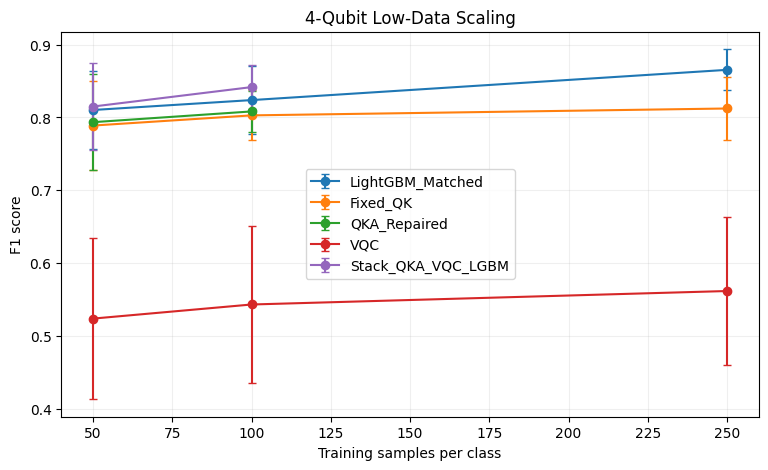

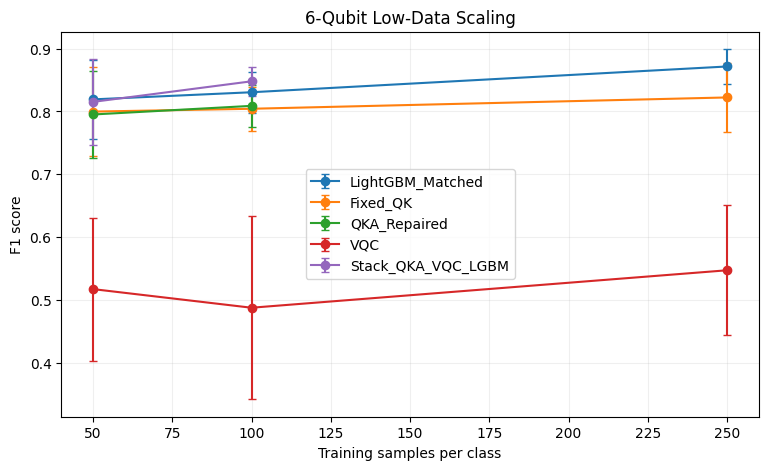

In [38]:
# Cell 38 — Paper figures — F1 vs data size
plot_models = [
    "LightGBM_Matched",
    "Fixed_QK",
    "QKA_Repaired",
    "VQC",
    "Stack_QKA_VQC_LGBM",
]

for nq in QUBITS:
    plt.figure(figsize=(9, 5))

    subset = clean[
        (clean["qubits"] == nq)
        & (clean["prototypes_per_class"] == 0)
        & (clean["model"].isin(plot_models))
    ]

    for model in plot_models:
        g = subset[subset["model"] == model]
        if len(g) == 0:
            continue

        agg = g.groupby("train_per_class")["f1"].agg(["mean", "std"])

        plt.errorbar(
            agg.index,
            agg["mean"],
            yerr=agg["std"],
            marker="o",
            capsize=3,
            label=model
        )

    plt.xlabel("Training samples per class")
    plt.ylabel("F1 score")
    plt.title(f"{nq}-Qubit Low-Data Scaling")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


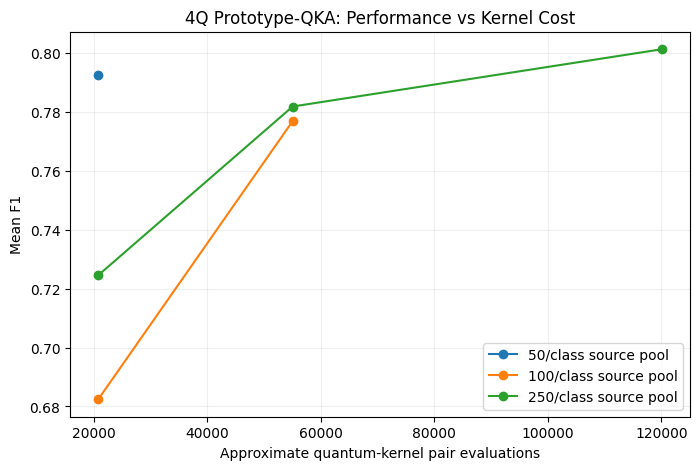

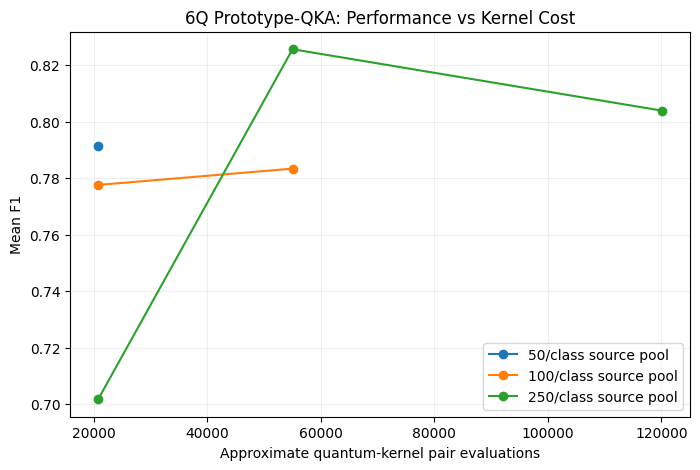

In [39]:
# Cell 39 — Paper figure — prototype QKA accuracy/cost trade-off
if len(proto_summary):
    for nq in QUBITS:
        subset = proto_summary[
            proto_summary["qubits"] == nq
        ]

        plt.figure(figsize=(8, 5))

        for ntrain in sorted(subset["train_per_class"].unique()):
            g = subset[
                subset["train_per_class"] == ntrain
            ].sort_values("approx_kernel_pairs")

            plt.plot(
                g["approx_kernel_pairs"],
                g["f1_mean"],
                marker="o",
                label=f"{ntrain}/class source pool"
            )

        plt.xlabel("Approximate quantum-kernel pair evaluations")
        plt.ylabel("Mean F1")
        plt.title(f"{nq}Q Prototype-QKA: Performance vs Kernel Cost")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()


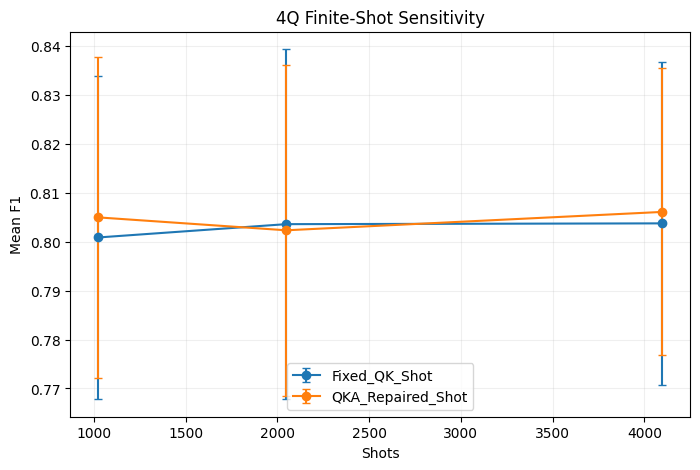

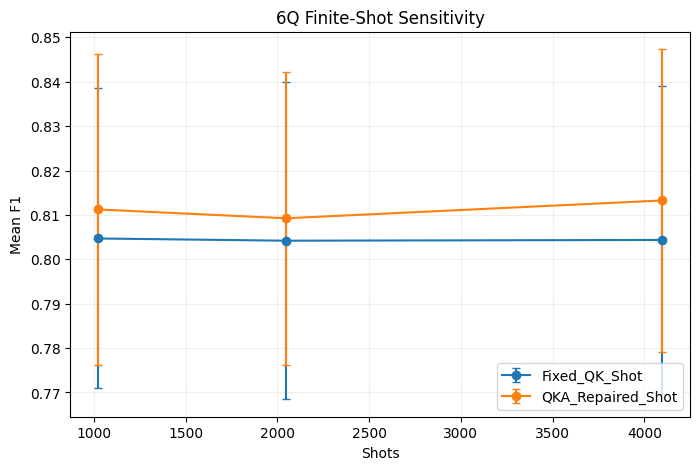

In [40]:
# Cell 40 — Paper figure — finite-shot sensitivity
if len(shot_summary):
    for nq in QUBITS:
        plt.figure(figsize=(8, 5))

        subset = shot_summary[
            shot_summary["qubits"] == nq
        ]

        for model in [
            "Fixed_QK_Shot",
            "QKA_Repaired_Shot"
        ]:
            g = subset[
                subset["model"] == model
            ].sort_values("shots")

            if len(g) == 0:
                continue

            plt.errorbar(
                g["shots"],
                g["f1_mean"],
                yerr=g["f1_sd"],
                marker="o",
                capsize=3,
                label=model
            )

        plt.xlabel("Shots")
        plt.ylabel("Mean F1")
        plt.title(f"{nq}Q Finite-Shot Sensitivity")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()


In [41]:
# Cell 41 — Final sanity checks for publication integrity
results_df = pd.DataFrame(list(RESULTS_BY_ID.values()))

checks = {
    "unique_experiment_ids": int(
        results_df["experiment_id"].nunique()
    ),
    "result_rows": int(len(results_df)),
    "duplicate_ids": int(
        results_df["experiment_id"].duplicated().sum()
    ),
    "duplicate_keys": int(
        results_df.duplicated(
            [
                "model", "seed", "qubits", "train_per_class",
                "prototypes_per_class", "shots", "scenario"
            ]
        ).sum()
    ),
    "seeds_present": sorted(
        results_df["seed"].dropna().astype(int).unique().tolist()
    ),
}

print(json.dumps(checks, indent=2))

assert checks["duplicate_ids"] == 0
assert checks["duplicate_keys"] == 0
assert set(SEEDS).issubset(set(checks["seeds_present"]))

print("Publication-integrity checks PASSED.")


{
  "unique_experiment_ids": 260,
  "result_rows": 260,
  "duplicate_ids": 0,
  "duplicate_keys": 0,
  "seeds_present": [
    11,
    22,
    33,
    44,
    55
  ]
}
Publication-integrity checks PASSED.


In [42]:
# Cell 42 — Save all V3 paper outputs
results_df = pd.DataFrame(list(RESULTS_BY_ID.values()))
predictions_df = pd.concat(PREDICTIONS_BY_ID.values(), ignore_index=True)

results_df.to_csv(OUT / "results_long.csv", index=False)
predictions_df.to_csv(OUT / "predictions_long.csv", index=False)
summary.to_csv(OUT / "summary_clean.csv", index=False)
ci_table.to_csv(OUT / "confidence_intervals_95.csv", index=False)
wilcoxon_df.to_csv(OUT / "wilcoxon_holm_tests.csv", index=False)
friedman_df.to_csv(OUT / "friedman_tests.csv", index=False)
mcnemar_df.to_csv(OUT / "mcnemar_tests.csv", index=False)
proto_summary.to_csv(OUT / "prototype_qka_summary.csv", index=False)
shot_summary.to_csv(OUT / "shot_summary.csv", index=False)

pd.DataFrame({
    "selected_feature": SELECTED_FEATURES
}).to_csv(
    OUT / "selected_features.csv",
    index=False
)

config = {
    "version": "PAPER_FULL_V3",
    "seeds": SEEDS,
    "qubits": QUBITS,
    "train_per_class": TRAIN_PER_CLASS_LIST,
    "validation_per_class": VAL_PER_CLASS,
    "test_per_class": TEST_PER_CLASS,
    "prototype_per_class": PROTOTYPES_PER_CLASS_LIST,
    "ae_epochs": AE_EPOCHS,
    "qka_maxiter": QKA_MAXITER,
    "vqc_maxiter": VQC_MAXITER,
    "shots": SHOT_LIST,
    "qka_repair": {
        "parameterization": QKA_PARAMETERIZATION,
        "optimizer": QKA_OPTIMIZER,
        "initialization": QKA_INITIALIZATION,
        "feature_map": "per-qubit RY + zz_feature_map(reps=1, entanglement=linear)",
        "kernel": "TrainableFidelityStatevectorKernel(shots=None)"
    },
    "full_qka_max_train_per_class": FULL_QKA_MAX_TRAIN_PER_CLASS,
    "allow_full_qka_250": ALLOW_FULL_QKA_250,
    "selected_features": SELECTED_FEATURES,
    "versions": {
        "qiskit": qiskit.__version__,
        "qiskit_machine_learning": qiskit_machine_learning.__version__,
        "torch": torch.__version__,
    }
}

with open(OUT / "experiment_config.json", "w") as f:
    json.dump(config, f, indent=2)

with open(OUT / "integrity_checks.json", "w") as f:
    json.dump(checks, f, indent=2)

print("Saved to:", OUT)

for p in sorted(OUT.iterdir()):
    print(" -", p.name)


Saved to: /content/drive/MyDrive/PhD_Work/NA_HQKVE_IDS_V3
 - confidence_intervals_95.csv
 - experiment_config.json
 - friedman_tests.csv
 - integrity_checks.json
 - mcnemar_tests.csv
 - predictions_long.csv
 - prototype_qka_summary.csv
 - results_long.csv
 - selected_features.csv
 - shot_summary.csv
 - summary_clean.csv
 - wilcoxon_holm_tests.csv


In [43]:
# Cell 43 — Create one ZIP package for the paper analysis
zip_path = shutil.make_archive(
    "/content/NA_HQKVE_IDS_PAPER_FULL_V3",
    "zip",
    str(OUT)
)

print("Created:", zip_path)

from google.colab import files
files.download(zip_path)


Created: /content/NA_HQKVE_IDS_PAPER_FULL_V3.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cell 44 — Recommended paper interpretation workflow

After the V3 run, use the outputs in this order:

1. **`summary_clean.csv`**  
   Identify the best mean model/configuration over five seeds.

2. **`confidence_intervals_95.csv`**  
   Report mean ± SD and 95% CI, not single best-run accuracy.

3. **`wilcoxon_holm_tests.csv`**  
   Use only Holm-adjusted results for planned pairwise claims.

4. **`friedman_tests.csv`**  
   Report whether the multi-model difference is significant within each 4Q/6Q and data-size condition.

5. **`mcnemar_tests.csv`**  
   Use paired prediction disagreement to support test-set error comparisons.

6. **`prototype_qka_summary.csv`**  
   Quantify the performance/cost trade-off of prototype reduction.

7. **`shot_summary.csv`**  
   Describe finite-shot sensitivity before IBM hardware validation.

8. **`results_long.csv` + `predictions_long.csv`**  
   Keep these as the reproducibility master files.

### Main defensible research questions

- Does repaired QKA outperform the fixed quantum kernel?
- Does the advantage persist across five seeds?
- Does 6Q provide a meaningful improvement over 4Q?
- Does prototype reduction preserve QKA performance while reducing kernel evaluations?
- Does the ensemble add value beyond matched-data LightGBM?
- Are finite-shot results stable enough to justify IBM hardware validation?

### Important
Do not claim universal quantum advantage. A stronger conclusion is conditional:

**Under specific low-data and low-dimensional conditions, does the repaired trainable quantum kernel or hybrid ensemble provide statistically supported complementary value relative to fixed quantum and classical baselines, and at what quantum-resource cost?**